# Notebook 29 - Package-backed final output path

This notebook tries the new `ultrasound_tracker.final_output` helpers.

The clean final-output path is now package code, not notebook-only formula code:

```text
ANG = dohough weighted-median alpha
PEN = ANG - superficial aponeurosis angle
FL  = muscle_thickness / sin(PEN)
```

The notebook checks three things:

1. The package helper reproduces the notebook 23 hand-written formula outputs.
2. The line-based helper reproduces the component-based helper when given saved aponeurosis lines.
3. The package-backed output has the same raw and baseline-normalized behavior observed in notebook 28.

In [1]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import Markdown, display

from ultrasound_tracker.final_output import (
    final_outputs_from_components,
    final_outputs_from_lines,
    image_depth_to_mm_per_pixel,
)
from ultrasound_tracker.matlab_compat import (
    compute_metrics,
    extract_final_region_arrays,
    load_matlab_result,
)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

VIDEO_PATH = PROJECT_ROOT / "data" / "raw" / "UltraTimTrack_test.mp4"
MATLAB_RESULT = PROJECT_ROOT / "data" / "matlab" / "slow_low_01_DOWN_tracked_Q=001.mat"
PY23_NPZ = PROJECT_ROOT / "results" / "timtrack_sequence_dohough_alpha_features_arrays.npz"
OUT_DIR = PROJECT_ROOT / "results" / "matlab_comparison"
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_CANDIDATE_CSV = OUT_DIR / "notebook29_package_final_output_candidate.csv"
OUT_METRICS_CSV = OUT_DIR / "notebook29_package_final_output_metrics.csv"
OUT_BASELINE_CSV = OUT_DIR / "notebook29_package_final_output_baselines.csv"
OUT_NPZ = OUT_DIR / "notebook29_package_final_output_arrays.npz"

plt.style.use("default")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

for path in [VIDEO_PATH, MATLAB_RESULT, PY23_NPZ]:
    print(path, "exists=", path.exists())

/Users/grosbedou/PycharmProjects/NDORMS/data/raw/UltraTimTrack_test.mp4 exists= True
/Users/grosbedou/PycharmProjects/NDORMS/data/matlab/slow_low_01_DOWN_tracked_Q=001.mat exists= True
/Users/grosbedou/PycharmProjects/NDORMS/results/timtrack_sequence_dohough_alpha_features_arrays.npz exists= True


## 1. Load inputs

The Python arrays come from notebook 23. That run already saved the current alpha, superficial aponeurosis angle, thickness, and aponeurosis lines.

In [2]:
mat = load_matlab_result(MATLAB_RESULT)
mat_region = extract_final_region_arrays(mat)
py = np.load(PY23_NPZ)

cap = cv2.VideoCapture(str(VIDEO_PATH))
fps = cap.get(cv2.CAP_PROP_FPS)
ret, frame0 = cap.read()
cap.release()
if not ret:
    raise RuntimeError(f"Could not read first frame from {VIDEO_PATH}")

mm_per_pixel = image_depth_to_mm_per_pixel(mat_region["image_depth_mm"], frame0.shape[0])

n = min(len(mat_region["fascicle_angle_deg"]), len(py["fascicle_angle_deg"]))
frame = np.asarray(py["frame"][:n], dtype=int)
time_s = np.asarray(py["time_s"][:n], dtype=float)

mat_ang = np.asarray(mat_region["fascicle_angle_deg"][:n], dtype=float)
mat_pen = np.asarray(mat_region["pennation_deg"][:n], dtype=float)
mat_fl = np.asarray(mat_region["length_mm"][:n], dtype=float)

py_alpha = np.asarray(py["fascicle_angle_deg"][:n], dtype=float)
py_super_angle = np.asarray(py["super_apo_angle_deg"][:n], dtype=float)
py_thickness = np.asarray(py["muscle_thickness_px"][:n], dtype=float)
py_saved_pen = np.asarray(py["pennation_angle_deg"][:n], dtype=float)
py_saved_fl_px = np.asarray(py["matlab_formula_fascicle_length_px"][:n], dtype=float)
py_selected_fl_mm = np.asarray(py["selected_line_length_px"][:n], dtype=float) * mm_per_pixel
sup_lines = np.asarray(py["sup_apo_lines"][:n], dtype=float)
deep_lines = np.asarray(py["deep_apo_lines"][:n], dtype=float)

print("Aligned frames:", n)
print("FPS:", fps)
print("mm_per_pixel:", mm_per_pixel)

Aligned frames: 2666
FPS: 33.341
mm_per_pixel: 0.09021352313167261


## 2. Run package final-output helpers

The component helper is the most direct path for arrays already produced by the sequence pipeline.

The line helper is useful when the sequence pipeline has alpha and aponeurosis lines but has not yet separately stored angle/thickness.

In [3]:
component_out = final_outputs_from_components(
    alpha_deg=py_alpha,
    aponeurosis_angle_deg=py_super_angle,
    thickness_px=py_thickness,
    mm_per_pixel=mm_per_pixel,
)

line_out = final_outputs_from_lines(
    alpha_deg=py_alpha,
    superficial_apo_lines=sup_lines,
    deep_apo_lines=deep_lines,
    x_eval=20.0,
    pennation_reference="superficial",
    mm_per_pixel=mm_per_pixel,
)

candidate = pd.DataFrame({
    "frame": frame,
    "time_s": time_s,
    "ANG_deg": component_out["ANG_deg"],
    "PEN_deg": component_out["PEN_deg"],
    "FL_px": component_out["FL_px"],
    "FL_mm": component_out["FL_mm"],
    "selected_segment_FL_mm": py_selected_fl_mm,
    "super_apo_angle_deg": py_super_angle,
    "muscle_thickness_px": py_thickness,
    "line_helper_PEN_deg": line_out["PEN_deg"],
    "line_helper_FL_mm": line_out["FL_mm"],
})

candidate.to_csv(OUT_CANDIDATE_CSV, index=False)
display(candidate.head())
print("Saved candidate output:", OUT_CANDIDATE_CSV)

,frame,time_s,ANG_deg,PEN_deg,FL_px,FL_mm,selected_segment_FL_mm,super_apo_angle_deg,muscle_thickness_px,line_helper_PEN_deg,line_helper_FL_mm
0,0,0.000000,24.0,25.415696,638.500572,57.601386,72.670027,-1.415696,274.033325,25.415696,57.601387
1,1,0.029993,24.0,25.415696,639.466835,57.688556,72.794847,-1.415696,274.448029,25.415696,57.688554
2,2,0.059986,23.0,24.415696,663.296173,59.838285,72.709572,-1.415696,274.176056,24.415696,59.838283
3,3,0.089979,24.0,25.415696,638.933538,57.640446,70.367506,-1.415696,274.219147,25.415696,57.640446
4,4,0.119972,23.0,24.415696,662.846701,59.797736,72.673672,-1.415696,273.990265,24.415696,59.797734


Saved candidate output: /Users/grosbedou/PycharmProjects/NDORMS/results/matlab_comparison/notebook29_package_final_output_candidate.csv


## 3. Sanity checks against notebook 23 values

These should be near zero. If not, the package helper does not faithfully represent the formula we validated in notebooks 24, 27, and 28.

In [4]:
def max_abs_diff(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    return float(np.nanmax(np.abs(a - b)))

sanity = pd.DataFrame([
    {
        "check": "component ANG vs saved alpha",
        "max_abs_diff": max_abs_diff(component_out["ANG_deg"], py_alpha),
        "unit": "deg",
    },
    {
        "check": "component PEN vs saved pennation",
        "max_abs_diff": max_abs_diff(component_out["PEN_deg"], py_saved_pen),
        "unit": "deg",
    },
    {
        "check": "component FL_px vs saved formula length",
        "max_abs_diff": max_abs_diff(component_out["FL_px"], py_saved_fl_px),
        "unit": "px",
    },
    {
        "check": "line helper PEN vs component PEN",
        "max_abs_diff": max_abs_diff(line_out["PEN_deg"], component_out["PEN_deg"]),
        "unit": "deg",
    },
    {
        "check": "line helper FL_mm vs component FL_mm",
        "max_abs_diff": max_abs_diff(line_out["FL_mm"], component_out["FL_mm"]),
        "unit": "mm",
    },
])

display(sanity)

,check,max_abs_diff,unit
0,component ANG vs saved alpha,0.000000e+00,deg
1,component PEN vs saved pennation,1.907349e-06,deg
2,component FL_px vs saved formula length,6.849748e-05,px
3,line helper PEN vs component PEN,5.950361e-08,deg
4,line helper FL_mm vs component FL_mm,3.942110e-06,mm


## 4. Raw and baseline-normalized metrics

As in notebook 28, each signal uses its own median over the same first-100-frame baseline window. This helps separate ROI/rest offset from movement dynamics.

In [5]:
BASELINE_START = 0
BASELINE_STOP = 100
baseline_mask = np.zeros(n, dtype=bool)
baseline_mask[BASELINE_START:min(BASELINE_STOP, n)] = True

signals = {
    "ANG_deg": {"matlab": mat_ang, "python": component_out["ANG_deg"], "unit": "deg"},
    "PEN_deg": {"matlab": mat_pen, "python": component_out["PEN_deg"], "unit": "deg"},
    "FL_mm": {"matlab": mat_fl, "python": component_out["FL_mm"], "unit": "mm"},
}

baseline_rows = []
for name, item in signals.items():
    m0 = float(np.nanmedian(item["matlab"][baseline_mask]))
    p0 = float(np.nanmedian(item["python"][baseline_mask]))
    item["matlab_baseline"] = m0
    item["python_baseline"] = p0
    item["matlab_delta"] = item["matlab"] - m0
    item["python_delta"] = item["python"] - p0
    baseline_rows.append({
        "signal": name,
        "unit": item["unit"],
        "matlab_baseline": m0,
        "python_baseline": p0,
        "python_minus_matlab_baseline": p0 - m0,
    })

baseline_df = pd.DataFrame(baseline_rows)
baseline_df.to_csv(OUT_BASELINE_CSV, index=False)
display(baseline_df)
print("Saved baselines:", OUT_BASELINE_CSV)

,signal,unit,matlab_baseline,python_baseline,python_minus_matlab_baseline
0,ANG_deg,deg,21.404714,24.000000,2.595286
1,PEN_deg,deg,22.315577,24.681308,2.365731
2,FL_mm,mm,63.150415,58.321724,-4.828692


Saved baselines: /Users/grosbedou/PycharmProjects/NDORMS/results/matlab_comparison/notebook29_package_final_output_baselines.csv


In [6]:
def metric_row(name, reference, estimate, unit):
    row = {"comparison": name, "unit": unit}
    row.update(compute_metrics(reference, estimate))
    return row

metric_rows = []
for name, item in signals.items():
    label = name.replace("_", " ")
    metric_rows.append(metric_row(f"raw {label}", item["matlab"], item["python"], item["unit"]))
    metric_rows.append(metric_row(f"delta {label}", item["matlab_delta"], item["python_delta"], item["unit"]))

metrics = pd.DataFrame(metric_rows)
metrics.to_csv(OUT_METRICS_CSV, index=False)
display(metrics)
print("Saved metrics:", OUT_METRICS_CSV)

,comparison,unit,n,bias,mae,rmse,corr
0,raw ANG deg,deg,2666,2.351215,2.382489,2.612432,0.968938
1,delta ANG deg,deg,2666,-0.244071,0.912090,1.164543,0.968938
2,raw PEN deg,deg,2666,1.642799,1.754320,2.040973,0.960301
3,delta PEN deg,deg,2666,-0.722932,1.103757,1.410465,0.960301
4,raw FL mm,mm,2666,-4.993747,5.115188,5.730871,0.954772
5,delta FL mm,mm,2666,-0.165055,2.253665,2.816491,0.954772


Saved metrics: /Users/grosbedou/PycharmProjects/NDORMS/results/matlab_comparison/notebook29_package_final_output_metrics.csv


## 5. Plots

The selected-segment length is shown as a warning/reference only. The package final output uses formula-based `FL`.

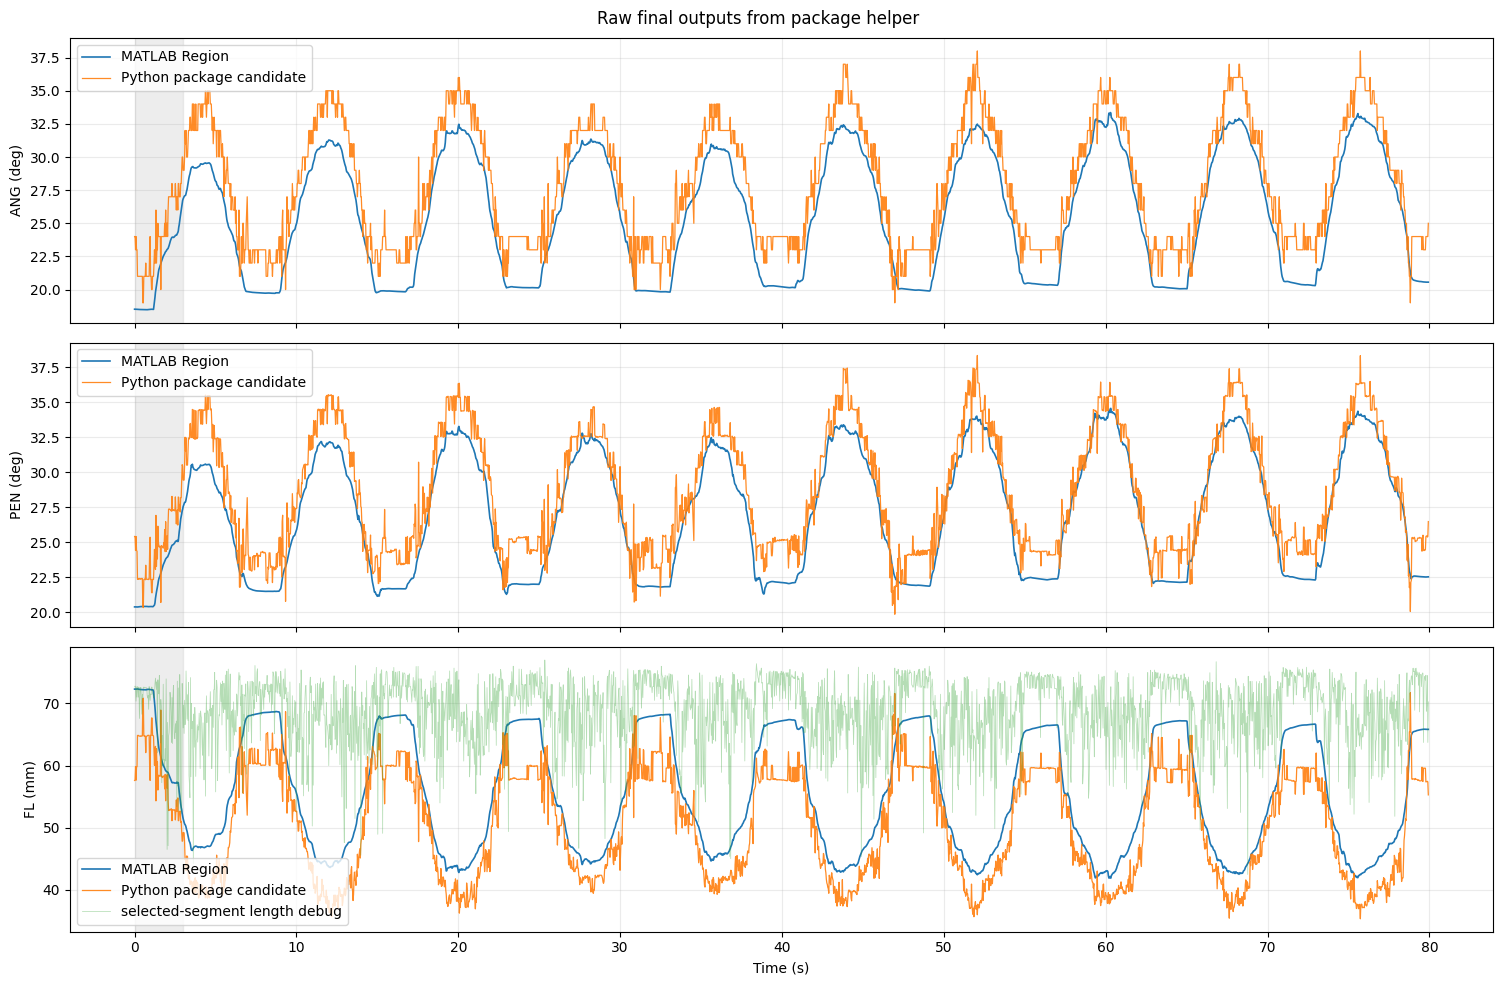

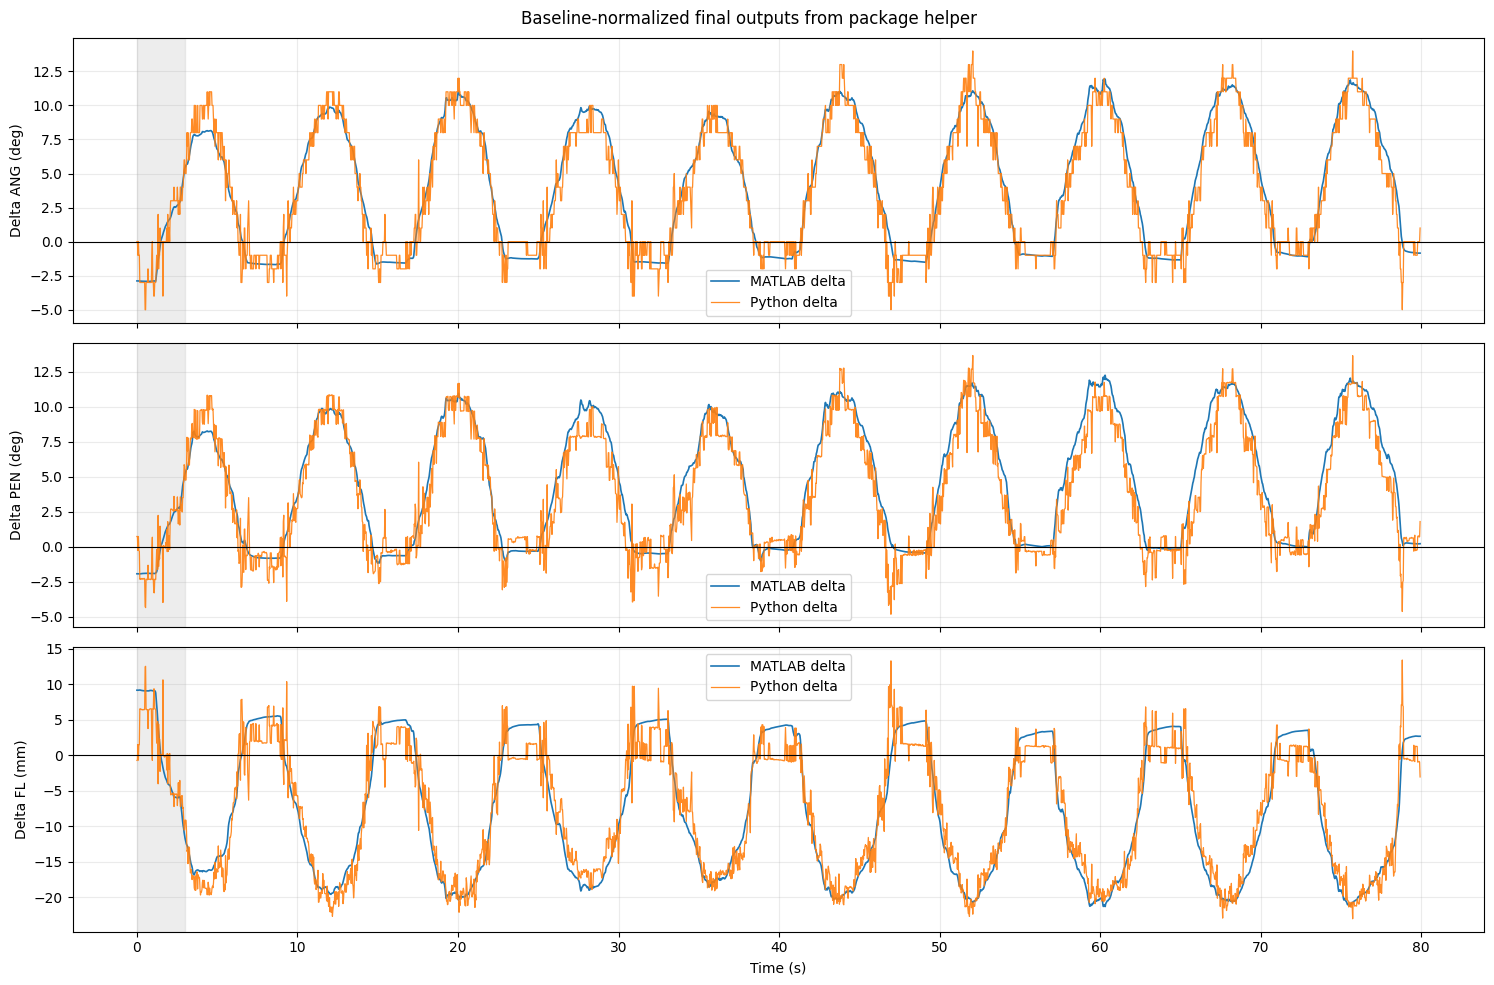

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)
plot_specs = [
    ("ANG_deg", "ANG (deg)"),
    ("PEN_deg", "PEN (deg)"),
    ("FL_mm", "FL (mm)"),
]

for ax, (name, ylabel) in zip(axes, plot_specs):
    item = signals[name]
    ax.plot(time_s, item["matlab"], label="MATLAB Region", linewidth=1.2)
    ax.plot(time_s, item["python"], label="Python package candidate", linewidth=0.9, alpha=0.9)
    if name == "FL_mm":
        ax.plot(time_s, py_selected_fl_mm, label="selected-segment length debug", linewidth=0.55, alpha=0.35)
    ax.axvspan(time_s[baseline_mask][0], time_s[baseline_mask][-1], color="0.8", alpha=0.35)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.25)
    ax.legend()

axes[-1].set_xlabel("Time (s)")
fig.suptitle("Raw final outputs from package helper")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)
for ax, (name, ylabel) in zip(axes, plot_specs):
    item = signals[name]
    ax.plot(time_s, item["matlab_delta"], label="MATLAB delta", linewidth=1.2)
    ax.plot(time_s, item["python_delta"], label="Python delta", linewidth=0.9, alpha=0.9)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.axvspan(time_s[baseline_mask][0], time_s[baseline_mask][-1], color="0.8", alpha=0.35)
    ax.set_ylabel("Delta " + ylabel)
    ax.grid(True, alpha=0.25)
    ax.legend()

axes[-1].set_xlabel("Time (s)")
fig.suptitle("Baseline-normalized final outputs from package helper")
plt.tight_layout()
plt.show()

## 6. Decision checkpoint

If the sanity checks are near zero and the metrics match notebook 28, the package helper is ready to become the output path used by the sequence pipeline.

Recommended package behavior:

- Keep `selected_segment_FL` only as a debug/visualization value.
- Use package-backed `ANG/PEN/FL` as the main final output columns.
- Keep baseline normalization in validation notebooks, not inside tracker output.

In [8]:
np.savez(
    OUT_NPZ,
    frame=frame,
    time_s=time_s,
    mm_per_pixel=mm_per_pixel,
    ANG_deg=component_out["ANG_deg"],
    PEN_deg=component_out["PEN_deg"],
    FL_px=component_out["FL_px"],
    FL_mm=component_out["FL_mm"],
    selected_segment_FL_mm=py_selected_fl_mm,
    matlab_ANG_deg=mat_ang,
    matlab_PEN_deg=mat_pen,
    matlab_FL_mm=mat_fl,
    ANG_delta=signals["ANG_deg"]["python_delta"],
    PEN_delta=signals["PEN_deg"]["python_delta"],
    FL_delta=signals["FL_mm"]["python_delta"],
    matlab_ANG_delta=signals["ANG_deg"]["matlab_delta"],
    matlab_PEN_delta=signals["PEN_deg"]["matlab_delta"],
    matlab_FL_delta=signals["FL_mm"]["matlab_delta"],
)
print("Saved arrays:", OUT_NPZ)

Saved arrays: /Users/grosbedou/PycharmProjects/NDORMS/results/matlab_comparison/notebook29_package_final_output_arrays.npz
